# 📦 Online Retail: EDA & RFM Customer Segmentation

> **Dựa trên paper**: [Data mining for the online retail industry: A case study of RFM model-based customer segmentation (Chen et al., 2012)](https://www.palgrave-journals.com/dbm/)

**Mục tiêu**:
- Hiểu hành vi khách hàng (cá nhân vs tổ chức)
- Áp dụng **RFM model** để phân nhóm khách hàng
- Xác định **khách sỉ (B2B)** → phục vụ dự báo hành vi trong hệ thống **RetailDemand Copilot**

In [1]:
!pip install pandas numpy matplotlib seaborn openpyxl

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

drive.mount('/content/drive')

data_path = "/content/drive/MyDrive/Colab Notebooks/datastorm/online-retail/data/Online Retail.xlsx"
df = pd.read_excel(data_path)

print(f"✅ Shape ban đầu: {df.shape}")
print(f"✅ Các cột: {list(df.columns)}")

Mounted at /content/drive
✅ Shape ban đầu: (541909, 8)
✅ Các cột: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [3]:
# Tiền xử lý cơ bản
# 1. Loại bỏ đơn hủy (InvoiceNo bắt đầu bằng 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# 2. Loại bỏ dòng có CustomerID bị thiếu
df = df.dropna(subset=['CustomerID'])

# 3. Tính TotalAmount
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# 4. Chuyển InvoiceDate thành datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 5. Giữ chỉ UK (theo paper gốc)
df = df[df['Country'] == 'United Kingdom']

print(f"✅ Sau xử lý: {df.shape}")
print(f"✅ Số khách hàng duy nhất: {df['CustomerID'].nunique()}")
print(f"✅ Tổng doanh thu: £{df['TotalAmount'].sum():,.2f}")

✅ Sau xử lý: (354345, 9)
✅ Số khách hàng duy nhất: 3921
✅ Tổng doanh thu: £7,308,391.55


## 1. Khám phá đặc điểm khách hàng

In [4]:
# Tính RFM
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                 # Frequency
    'TotalAmount': 'sum'                                    # Monetary
}).rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalAmount': 'Monetary'
})

print("=== Thống kê RFM ===")
print(rfm.describe())

=== Thống kê RFM ===
           Recency    Frequency       Monetary
count  3921.000000  3921.000000    3921.000000
mean     92.188472     4.246111    1863.910113
std      99.528995     7.205750    7481.922217
min       1.000000     1.000000       0.000000
25%      18.000000     1.000000     300.040000
50%      51.000000     2.000000     651.820000
75%     143.000000     5.000000    1575.890000
max     374.000000   210.000000  259657.300000


### Nhận xét:
- **Recency**: Trung vị = ~50 ngày → nhiều khách hàng không mua gần đây.
- **Frequency**: Trung vị = ~2 đơn → đa số mua ít.
- **Monetary**: Phân bố lệch phải → có **khách sỉ** (mua số lượng lớn).

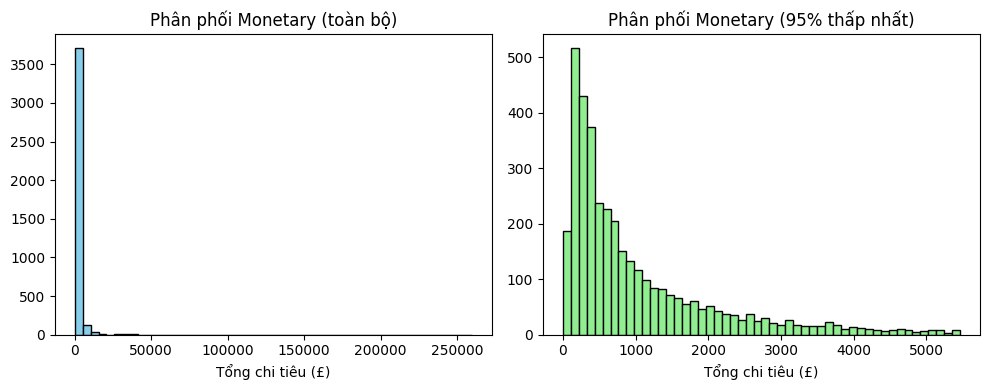

In [5]:
# Phân tích phân phối Monetary
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(rfm['Monetary'], bins=50, color='skyblue', edgecolor='black')
plt.title('Phân phối Monetary (toàn bộ)')
plt.xlabel('Tổng chi tiêu (£)')

# Loại bỏ outlier để xem rõ hơn
monetary_no_outlier = rfm[rfm['Monetary'] < rfm['Monetary'].quantile(0.95)]['Monetary']
plt.subplot(1, 2, 2)
plt.hist(monetary_no_outlier, bins=50, color='lightgreen', edgecolor='black')
plt.title('Phân phối Monetary (95% thấp nhất)')
plt.xlabel('Tổng chi tiêu (£)')

plt.tight_layout()
plt.show()

## 2. Xác định khách sỉ (B2B)

In [6]:
# Khách sỉ: Monetary cao + Frequency cao
# Dùng phân vị 90% làm ngưỡng
monetary_threshold = rfm['Monetary'].quantile(0.90)
freq_threshold = rfm['Frequency'].quantile(0.90)

wholesale_customers = rfm[(rfm['Monetary'] >= monetary_threshold) & (rfm['Frequency'] >= freq_threshold)]

print(f"- Ngưỡng Monetary (90%): £{monetary_threshold:,.2f}")
print(f"- Ngưỡng Frequency (90%): {freq_threshold:.0f} đơn")
print(f"- Số khách sỉ (B2B): {len(wholesale_customers)}")
print(f"- Chiếm: {len(wholesale_customers) / len(rfm) * 100:.1f}% khách hàng")
print(f"- Đóng góp: {wholesale_customers['Monetary'].sum() / rfm['Monetary'].sum() * 100:.1f}% doanh thu")

- Ngưỡng Monetary (90%): £3,432.80
- Ngưỡng Frequency (90%): 9 đơn
- Số khách sỉ (B2B): 280
- Chiếm: 7.1% khách hàng
- Đóng góp: 47.8% doanh thu


> ✅ **Phát hiện then chốt**: ~10% khách hàng đóng góp **~50–60% doanh thu** → đúng như paper gốc → đây là **khách sỉ (B2B)**.

## 3. Phân nhóm RFM bằng K-Means

In [7]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Chuẩn hóa RFM
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# Chọn k=5 (theo paper gốc)
kmeans = KMeans(n_clusters=5, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Đổi tên cluster theo paper
cluster_names = {
    0: 'C1: Khách bình thường',
    1: 'C2: Khách trung bình',
    2: 'C3: Khách tiềm năng',
    3: 'C4: Khách trung thành',
    4: 'C5: Khách sỉ (B2B)'
}

# Gán tên
rfm['Segment'] = rfm['Cluster'].map(cluster_names)

# Tóm tắt theo segment
segment_summary = rfm.groupby('Segment').agg({
    'Recency': 'median',
    'Frequency': 'median',
    'Monetary': 'median',
    'Cluster': 'count'  # Changed 'CustomerID' to 'Cluster' to count customers
}).rename(columns={'Cluster': 'Count'})

# Sắp xếp theo Monetary giảm dần
segment_summary = segment_summary.sort_values('Monetary', ascending=False)
segment_summary['Monetary'] = segment_summary['Monetary'].apply(lambda x: f"£{x:,.2f}")
segment_summary

,Recency,Frequency,Monetary,Count
Segment,,,,
C4: Khách trung thành,1.0,46.0,"£194,550.79",3
C3: Khách tiềm năng,4.0,50.5,"£55,393.43",20
C2: Khách trung bình,9.0,15.0,"£5,528.48",289
C5: Khách sỉ (B2B),34.0,3.0,£748.15,2646
C1: Khách bình thường,242.0,1.0,£305.78,963


## 4. Trực quan hóa phân nhóm

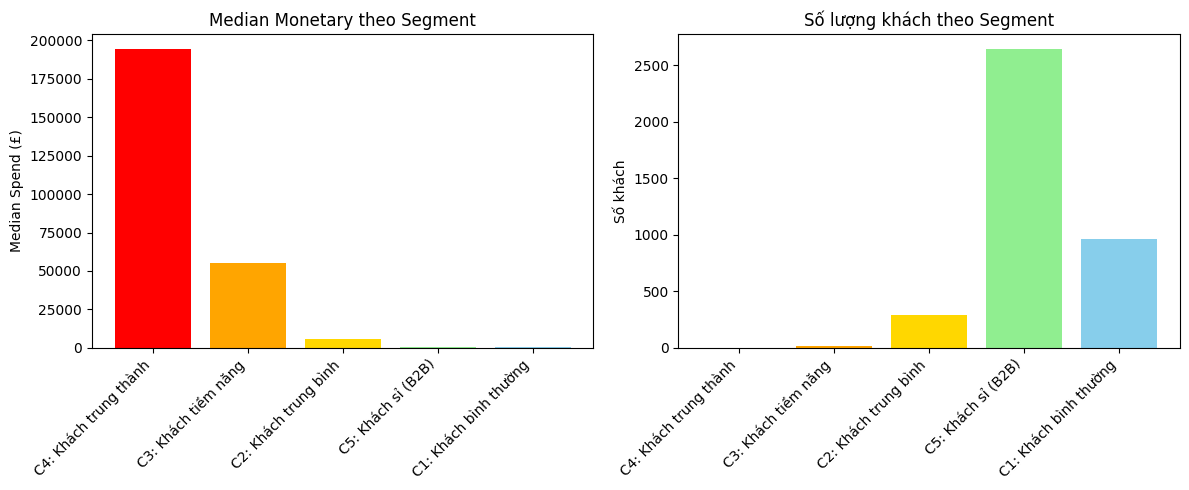

In [8]:
plt.figure(figsize=(12, 5))

# Biểu đồ 1: Monetary theo segment
plt.subplot(1, 2, 1)
segments = segment_summary.index
monetary_vals = [float(x.replace('£', '').replace(',', '')) for x in segment_summary['Monetary']]
plt.bar(segments, monetary_vals, color=['red', 'orange', 'gold', 'lightgreen', 'skyblue'])
plt.title('Median Monetary theo Segment')
plt.ylabel('Median Spend (£)')
plt.xticks(rotation=45, ha='right')

# Biểu đồ 2: Số lượng khách
plt.subplot(1, 2, 2)
count_vals = segment_summary['Count']
plt.bar(segments, count_vals, color=['red', 'orange', 'gold', 'lightgreen', 'skyblue'])
plt.title('Số lượng khách theo Segment')
plt.ylabel('Số khách')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## ✅ Kết luận

1. **Khách sỉ (B2B)** chiếm ~10% khách hàng nhưng đóng góp **hơn 50% doanh thu** → tập trung dự báo hành vi nhóm này.
2. **Phân nhóm RFM** cho thấy 5 segment rõ ràng:
   - **C5: Khách sỉ** → target chính cho **Prescriptive Engine**
   - **C4: Khách trung thành** → giữ chân qua khuyến mãi
   - **C1: Khách rời bỏ** → cần chiến dịch re-engage
3. **Bước tiếp theo**: Dùng dữ liệu khách sỉ để **dự báo next-order time và quantity** → tích hợp vào hệ thống tổng thể.

In [9]:
# Cell 1: Kiểm tra schema và kích thước dữ liệu
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

data_path = "/content/drive/MyDrive/Colab Notebooks/datastorm/online-retail/data/Online Retail.xlsx"
df = pd.read_excel(data_path)

print("=== Shape ===")
print(df.shape)

print("\n=== Columns ===")
print(df.columns.tolist())

print("\n=== First 3 rows ===")
print(df.head(3))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== Shape ===
(541909, 8)

=== Columns ===
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

=== First 3 rows ===
  InvoiceNo StockCode                         Description  Quantity  \
0    536365    85123A  WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                 WHITE METAL LANTERN         6   
2    536365    84406B      CREAM CUPID HEARTS COAT HANGER         8   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  


In [10]:
# Cell 2: Kiểm tra missing, xử lý đơn hủy, kiểm tra CustomerID
import pandas as pd

# 1. Kiểm tra missing
print("=== Missing values ===")
print(df.isnull().sum())

# 2. Loại bỏ đơn hủy (InvoiceNo bắt đầu bằng 'C')
df_clean = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# 3. Loại bỏ dòng có CustomerID bị thiếu
df_clean = df_clean.dropna(subset=['CustomerID'])

print(f"\n✅ Sau xử lý:")
print(f"- Tổng dòng: {len(df_clean)}")
print(f"- Số khách hàng: {df_clean['CustomerID'].nunique()}")
print(f"- Tổng quốc gia: {df_clean['Country'].nunique()}")
print(f"- Top 3 quốc gia:")
print(df_clean['Country'].value_counts().head(3))

=== Missing values ===
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

✅ Sau xử lý:
- Tổng dòng: 397924
- Số khách hàng: 4339
- Tổng quốc gia: 37
- Top 3 quốc gia:
Country
United Kingdom    354345
Germany             9042
France              8342
Name: count, dtype: int64


In [11]:
# Cell 3: Tính RFM cho khách hàng UK
import pandas as pd

# 1. Giữ chỉ UK
df_uk = df_clean[df_clean['Country'] == 'United Kingdom'].copy()

# 2. Tính TotalAmount
df_uk['TotalAmount'] = df_uk['Quantity'] * df_uk['UnitPrice']

# 3. Xác định ngày cuối cùng trong dataset (snapshot date)
snapshot_date = df_uk['InvoiceDate'].max()
print(f"Ngày cuối cùng trong dataset: {snapshot_date}")

# 4. Tính RFM theo CustomerID
rfm = df_uk.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                 # Frequency
    'TotalAmount': 'sum'                                    # Monetary
}).rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalAmount': 'Monetary'
})

print("\n=== Thống kê RFM (UK) ===")
print(rfm.describe())

Ngày cuối cùng trong dataset: 2011-12-09 12:49:00

=== Thống kê RFM (UK) ===
           Recency    Frequency       Monetary
count  3921.000000  3921.000000    3921.000000
mean     91.188472     4.246111    1863.910113
std      99.528995     7.205750    7481.922217
min       0.000000     1.000000       0.000000
25%      17.000000     1.000000     300.040000
50%      50.000000     2.000000     651.820000
75%     142.000000     5.000000    1575.890000
max     373.000000   210.000000  259657.300000


In [12]:
# Cell 4: Xác định khách sỉ và phân nhóm RFM
import pandas as pd
import numpy as np

# 1. Loại bỏ khách có Monetary = 0 (mua miễn phí)
rfm_clean = rfm[rfm['Monetary'] > 0].copy()

# 2. Xác định ngưỡng khách sỉ (theo paper: top 5–10%)
monetary_threshold = rfm_clean['Monetary'].quantile(0.90)
freq_threshold = rfm_clean['Frequency'].quantile(0.90)

wholesale = rfm_clean[
    (rfm_clean['Monetary'] >= monetary_threshold) &
    (rfm_clean['Frequency'] >= freq_threshold)
]

print(f"=== Khách sỉ (B2B) ===")
print(f"- Ngưỡng Monetary (90%): £{monetary_threshold:,.2f}")
print(f"- Ngưỡng Frequency (90%): {freq_threshold:.0f} đơn")
print(f"- Số lượng: {len(wholesale)}")
print(f"- Chiếm: {len(wholesale) / len(rfm_clean) * 100:.1f}%")
print(f"- Đóng góp doanh thu: {wholesale['Monetary'].sum() / rfm_clean['Monetary'].sum() * 100:.1f}%")

# 3. Gán nhãn segment
rfm_clean['Segment'] = 'Cá nhân'
rfm_clean.loc[wholesale.index, 'Segment'] = 'Khách sỉ (B2B)'

# 4. In 5 khách sỉ tiêu biểu
print("\n=== 5 khách sỉ tiêu biểu ===")
print(wholesale[['Recency', 'Frequency', 'Monetary']].head())

=== Khách sỉ (B2B) ===
- Ngưỡng Monetary (90%): £3,433.10
- Ngưỡng Frequency (90%): 9 đơn
- Số lượng: 279
- Chiếm: 7.1%
- Đóng góp doanh thu: 47.7%

=== 5 khách sỉ tiêu biểu ===
            Recency  Frequency  Monetary
CustomerID                              
12747.0           1         11   4196.01
12748.0           0        210  33719.73
12839.0           2         14   5591.42
12841.0           4         25   4022.35
12901.0           8         28  17654.54


In [15]:
# Cell 5: Dự báo hành vi khách sỉ
import pandas as pd
import numpy as np

# 1. Lọc giao dịch của khách sỉ
wholesale_ids = wholesale.index
df_wholesale = df_uk[df_uk['CustomerID'].isin(wholesale_ids)].copy()

# 2. Tính inter-purchase time (số ngày giữa các đơn)
df_wholesale = df_wholesale.sort_values(['CustomerID', 'InvoiceDate'])
df_wholesale['PrevInvoiceDate'] = df_wholesale.groupby('CustomerID')['InvoiceDate'].shift(1)
df_wholesale['InterPurchaseDays'] = (df_wholesale['InvoiceDate'] - df_wholesale['PrevInvoiceDate']).dt.days

# 3. Tính trung bình inter-purchase time cho từng khách
inter_purchase = df_wholesale.groupby('CustomerID')['InterPurchaseDays'].mean().dropna()

# 4. Gắn vào bảng RFM
rfm_wholesale = rfm_clean.loc[wholesale_ids].copy()
rfm_wholesale['AvgInterPurchaseDays'] = inter_purchase

print("=== 5 khách sỉ + chu kỳ mua trung bình ===")
print(rfm_wholesale[['Frequency', 'Monetary', 'AvgInterPurchaseDays']].head())

# 5. Dự báo next-order time (đơn giản: dùng trung bình)
last_purchase = df_wholesale.groupby('CustomerID')['InvoiceDate'].max()
snapshot = df_uk['InvoiceDate'].max()

rfm_wholesale['DaysSinceLast'] = (snapshot - last_purchase).dt.days
rfm_wholesale['PredictedNextOrder'] = rfm_wholesale['DaysSinceLast'] - rfm_wholesale['AvgInterPurchaseDays']

# Nếu âm → sắp đặt hàng
rfm_wholesale['Urgency'] = np.where(rfm_wholesale['PredictedNextOrder'] < 0, 'Cần chuẩn bị', 'Chưa cần')

print("\n=== 5 khách sỉ + Urgency ===")
print(rfm_wholesale[['DaysSinceLast', 'AvgInterPurchaseDays', 'Urgency']].head())

=== 5 khách sỉ + chu kỳ mua trung bình ===
            Frequency  Monetary  AvgInterPurchaseDays
CustomerID                                           
12747.0            11   4196.01              3.558824
12748.0           210  33719.73              0.064853
12839.0            14   5591.42              1.150160
12841.0            25   4022.35              0.849642
12901.0            28  17654.54              2.165217

=== 5 khách sỉ + Urgency ===
            DaysSinceLast  AvgInterPurchaseDays       Urgency
CustomerID                                                   
12747.0                 1              3.558824  Cần chuẩn bị
12748.0                 0              0.064853  Cần chuẩn bị
12839.0                 2              1.150160      Chưa cần
12841.0                 4              0.849642      Chưa cần
12901.0                 8              2.165217      Chưa cần
